---
title: Hexbin Plots
subtitle: DS 2023 | Communicating with Data
---

## Overview

One limitation of a scatterplot is that it doesn't do a good job of showing how many data points exists at a specific location. 

The problem is called **occlusion** become some data point representations occlude others.

In the case of the Penguins data set, you can see that the three clusters have more points in their centroids, but it is not clear how many points are being covered up by other points.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
penguins = sns.load_dataset('penguins').dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


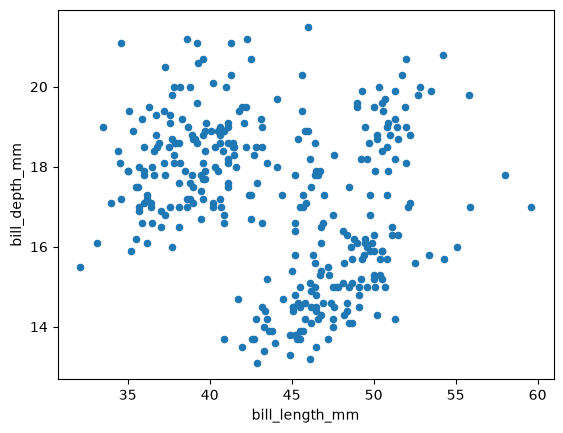

In [37]:
penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm')
plt.show()

One way to address the problem is to set the `alpha` parameter to a number less than $1$. 

In graphics, the variable alpha $\alpha$ stands for the color opacity of a visual element.

With a low alpha, stacked points appear darker because the colors of overlapping data points add up.

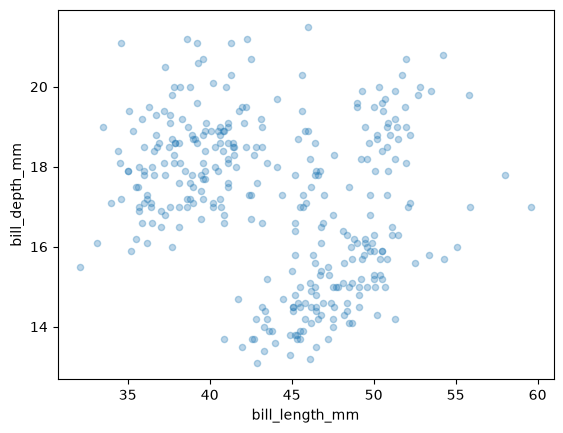

In [38]:
penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm', alpha=.3)
plt.show()

This is good, but we can do better.

Another approach is to divide the space into cells and color each cell as a function of the number of data points in the cell.

Pandas provides a `.plot.hexbin()` method that divides the space into hexagons and shades them by the concentration of data points.

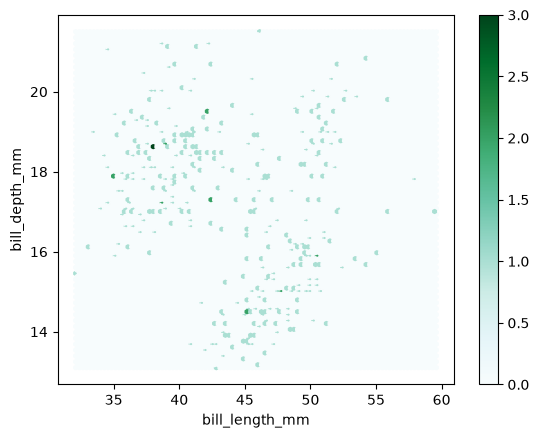

In [26]:
penguins.plot.hexbin(x='bill_length_mm', y='bill_depth_mm')
plt.show()

To get the most out of this method, it is best to choose a `gridsize` value large enough to group a significant number of points in eache cell.

Here we use a value of $25$.

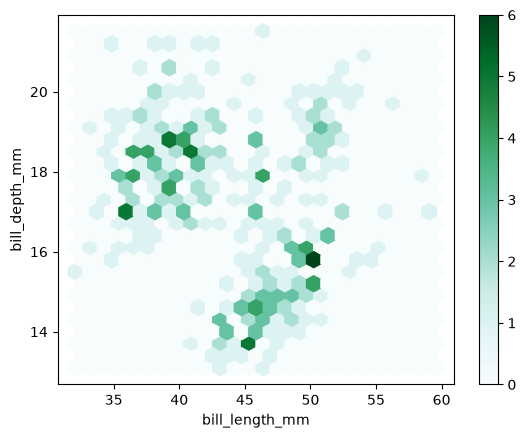

In [27]:
penguins.plot.hexbin(x='bill_length_mm', y='bill_depth_mm', gridsize=25)
plt.show()

Finally, we can choose a color map that accentuates the 

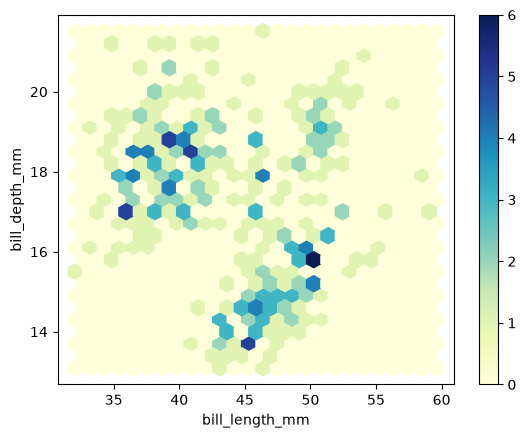

In [28]:
penguins.plot.hexbin(x='bill_length_mm', y='bill_depth_mm', gridsize=25, cmap="YlGnBu")
plt.show()

The resulting image is a kind of **heatmap**.

We'll review these in a later chapter.


## A better example

Let's look at a data set with more occulusion.

The following data set for heart disease in humans is from the UC Irvine Machine Learning Repository.

Conveniently, the data are avaiable through a Python page `ucimlrepo`.

In [57]:
from ucimlrepo import fetch_ucirepo 
  
heart_disease_raw = fetch_ucirepo(id=45) 
heart_disease_cols = heart_disease_raw.variables
heart_disease = heart_disease_raw.data['original']
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [67]:
# pd.plotting.scatter_matrix(heart_disease, figsize=(20, 20))
# plt.show()

Let's look at `age` vs `chol` (cholesterol).

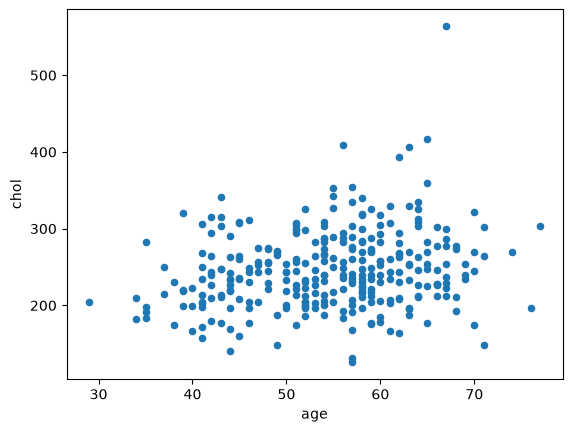

In [63]:
heart_disease.plot.scatter(x='age', y='chol')
plt.show()

A hexbin plot gives us a much better representation of the concentration of data.

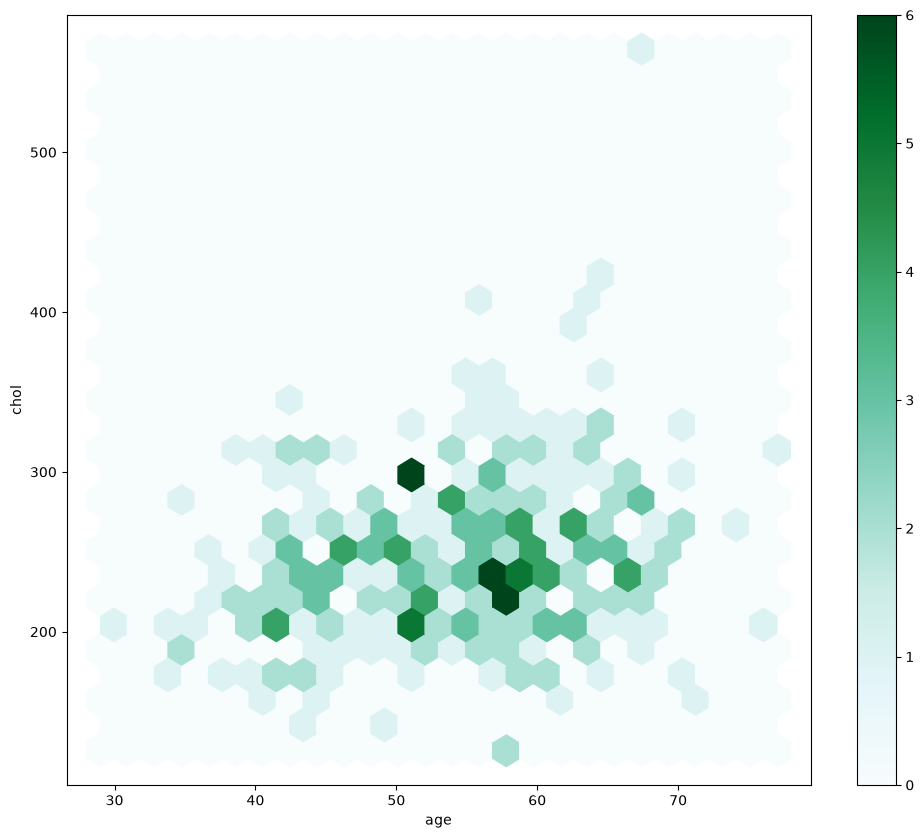

In [68]:
heart_disease.plot.hexbin(x='age', y='chol', gridsize=25, figsize=(12,10))
plt.show()

In [69]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
# metadata 
print(iris.metadata) 
  
# variable information 
print(iris.variables) 


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org